# TEM v1 Structural-Memory Hypothesis Report

**Claim:** The trained TEM v1 checkpoint reconstructs Arena observations through the inference pathway on a bounded validation slice. The report also exposes retrieved and ancestral pathway outputs qualitatively through Arena prediction overlays. The structural-memory hypothesis remains pending pathway-stratified, representation, remapping, and generalization diagnostics.

> **Status (2026-05-30):** This notebook is a **scientific scaffold**, not a finished report. It defines the evidence ladder and displays whatever evidence is currently available. Placeholder cells are marked with explicit contracts — they are implementation requirements, not missing work.
>
> **This notebook does NOT claim that TEM implements structural memory.** It defines the path to evaluate that hypothesis and reports progress against it.
>
> **Evidence quality note:** TEM v2 and EHC v1 are included as pipeline-readiness diagnostics only — their checkpoints are undertrained (TEM v2: global_step=76; EHC v1: global_step=1) and do not constitute valid comparison evidence.


## 1. Report Claim and Evidence Status

This report is organized around the TEM structural-memory hypothesis:

> TEM predicts sensory observations through a learned cognitive map organized by an entorhinal-cortex-like grid representation. Structural memory — the ability to reuse learned graph/topology knowledge across different sensory contexts — is the core claim of this family (Whittington et al., 2020, _Cell_; Whittington et al., 2022, _arXiv_).

### Evidence hierarchy

| Level | Claim                                                                | Current status                                                  |
| ----- | -------------------------------------------------------------------- | --------------------------------------------------------------- |
| 1     | TEM v1 reconstructs Arena observations through the inference pathway | ✅ Supported on bounded val_8                                   |
| 2     | TEM v1 exposes retrieved and ancestral prediction streams            | ✅ Qualitatively inspectable via `arena_prediction_overlay`     |
| 3     | Retrieved/ancestral pathways aid revisit reconstruction              | ⏳ Pending — metrics computed but not aggregated into ReportRun |
| 4     | TEM v1 learns structural codes separable from sensory content        | ❌ Pending — no MEC/HPC/remapping evidence yet                  |
| 5     | TEM v1 vs TEM v2/EHC comparison                                      | ❌ Not evaluated — TEM v2/EHC checkpoints undertrained          |

This report is **artifact-backed**: all displayed results derive from completed ReportRuns. No evaluation, adapter dispatch, metric computation, or figure generation runs in this notebook.


In [1]:
from ehc_sn.reporting import open_report

TEM_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n4"
TEM_V2_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n4"
EHC_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/ehc_v1/arena_n4"

# Primary evidence: TEM v1 only (trained checkpoint, interpretable).
primary_report = open_report(TEM_V1_REPORT_PATH)

# Diagnostic pipeline-readiness: TEM v2 and EHC v1 (undertrained checkpoints,
# included only to confirm the eval/report/figure path is functional).
# diagnostic_reports = {
#     "TEM v2": open_report("/home/borja/ehc-sn/artifacts/reports/tem_v2/arena_struct_val_8"),
#     "EHC v1": open_report("/home/borja/ehc-sn/artifacts/reports/ehc_v1/arena_struct_val_8"),
# }

## 2. Task Paradigm — Arena Replay Evaluation

This report evaluates models on the **Arena replay task**, also known as the dungeon-navigation replay task (Whittington et al., 2020, 2022).

**What is Arena?**

Arena is a structural-navigation task where an agent navigates a 2-D grid dungeon topology. At each step the agent occupies one passable cell and observes a categorical **observation ID** (a unique integer per cell). The agent can move in four cardinal directions (↑↓←→). The goal is to navigate through the dungeon from a random start position.

**What does the model predict?**

At each step `t`, the model receives the previous observation ID and the action taken, and must predict the observation ID at the next step `t+1`. This is a next-observation prediction task — a form of self-supervised learning on trajectories.

**What is a revisit?**

A **revisit** occurs when the agent occupies a cell it has already visited earlier in the same episode. Revisit steps are the primary structural-memory diagnostic: predicting the observation at a revisited location requires the model to recall information encountered earlier in the episode (or to use an internal representation of the environment's structure). High accuracy on revisit steps is **consistent with** structural memory, but does not by itself prove grid-like or hippocampal-like representations.

**What does the figure show?**

When available, the figure below shows the Arena environment for the first evaluation case:

- **Panel (a):** The dungeon topology with free cells coloured by observation ID.
- **Panel (b):** The agent's trajectory through the environment, coloured by time. Red stars mark revisit steps — points where the agent returns to a previously visited cell.


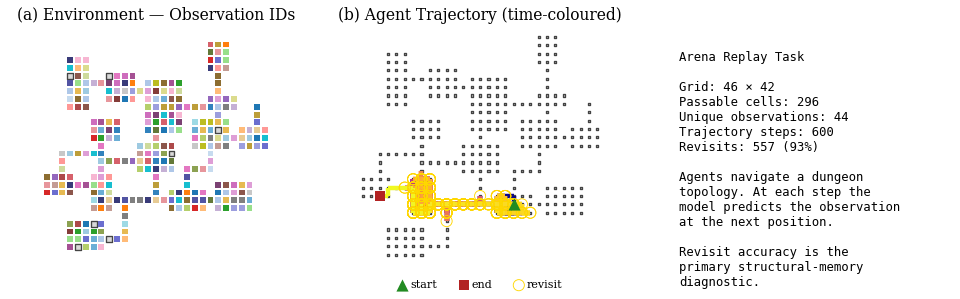

Figure: arena_task_overview | Format: png | Path: figures/0000-arena-test-0000-arena_task_overview.png


In [2]:
from IPython.display import Image, display as ipy_display

# Display the arena task overview figure (paradigm context, 1 entry).
figure_index = primary_report.figures()
overview_entries = []
if figure_index:
    overview_entries = [
        e for e in figure_index.entries if e.figure_id == "arena_task_overview"
    ]

if overview_entries:
    entry = overview_entries[0]
    abs_path = primary_report.root / entry.path
    ipy_display(Image(filename=str(abs_path)))
    print(f"Figure: {entry.figure_id} | Format: {entry.format} | Path: {entry.path}")
else:
    print("arena_task_overview not yet available in this ReportRun.")
    print("Rebuild the ReportRun from the updated config after regenerating")
    print("Arena eval artifacts with task evidence sidecars.")
    print("See: config/reporting/tem_v1_arena_n4.toml")

## 3. Evidence Source

The primary evidence comes from one coherent ReportRun:

- **ReportRun:** `artifacts/reports/tem_v1/arena_n4`
- **Model:** TEM v1
- **Checkpoint:** `checkpoints/tem-v1/eval-weights-only.pt` (global_step=10000, epoch=100)
- **Regime:** Arena n4 (4 validation cases, diagnostic, CPU)
- **Metrics:** `accuracy_all`, `accuracy_revisit`
- **Figures:** `arena_task_overview` (1 entry, paradigm) and `arena_prediction_overlay` (4 entries, 1 per case)

This ReportRun contains normalized metrics and rendered overlay figures from the same evaluation artifact.


## 4. Quantitative Evidence

The metrics below are aggregated from the **inference pathway only**. Retrieved and ancestral pathway accuracies are computed per-step but are not yet surfaced in the ReportRun metric records.

**Important:** These are inference-pathway observation reconstruction accuracies, not pathway-agnostic structural-memory metrics. A model that achieves 1.0 on both metrics may be solving autoencoding through large-capacity memory rather than through structural-code reuse.

| Metric             | Value | Unit  | Interpretation                                                           |
| ------------------ | ----- | ----- | ------------------------------------------------------------------------ |
| `accuracy_all`     | 1.0   | ratio | Inference pathway reconstructs all observations correctly on this slice. |
| `accuracy_revisit` | 1.0   | ratio | Inference pathway reconstructs revisit-step observations correctly.      |

**Bounded-validation note:** These values are from a 4-case validation slice. They are pipeline-backed evidence but not the canonical Arena-Struct benchmark.


### Inference-pathway metrics detail

```
accuracy_all       = correct_inference_all / count_all
accuracy_revisit   = correct_inference_revisit / count_revisit
```

Where `correct_inference_all` is the sum of `TEM_ACC_OBS_INFERENCE_ALL` numerator across all steps, and `count_all` is the sum of its denominator. The same pattern applies for revisit steps.

**Caveat:** If inference, retrieved, and ancestral streams all produce identical argmax on every step — which is plausible at 1.0 accuracy — comparison of pathway accuracies alone cannot distinguish structural memory from memorization. In that case, code-level divergence and representation geometry become the relevant evidence.


In [3]:
# Primary metrics from the ReportRun
metrics = primary_report.metrics()
print(f"Model family: {primary_report.model_family}")
print(f"Metric count: {len(metrics)}")
print()
for m in metrics:
    hb = (
        "(higher is better)"
        if m.higher_is_better
        else "(lower is better)" if m.higher_is_better is not None else ""
    )
    print(f"  {m.metric:<30s} {m.value:<12} {m.unit if m.unit else '—':<10s} {hb}")

Model family: tem-v1
Metric count: 2

  accuracy_all                   1.0          ratio      (higher is better)
  accuracy_revisit               1.0          ratio      (higher is better)


## 5. Qualitative Evidence — Prediction Overlays

The `arena_prediction_overlay` figures are indexed in the primary ReportRun's `FigureIndex`. Each figure compares ground-truth observation IDs with three prediction streams (inference, retrieved, ancestral) across a validation episode.

**What the overlay shows:**

- Ground-truth observation sequence (`gt`)
- Inference pathway argmax prediction
- Retrieved (memory) pathway argmax prediction
- Ancestral (structural prior) pathway argmax prediction

**What the overlay does NOT show:**

- Confidence or softmax probability of the winning class
- Logit margins (how close the runner-up was)
- Top-k alternative predictions
- Pathway uncertainty

The overlay is an argmax comparison — it shows _which_ class each pathway predicts, but not _how confidently_.

Below is the first case's overlay figure, followed by a complete list of all available overlay entries.


Total arena_prediction_overlay entries: 8

Exemplar — case=arena_n4 format=png


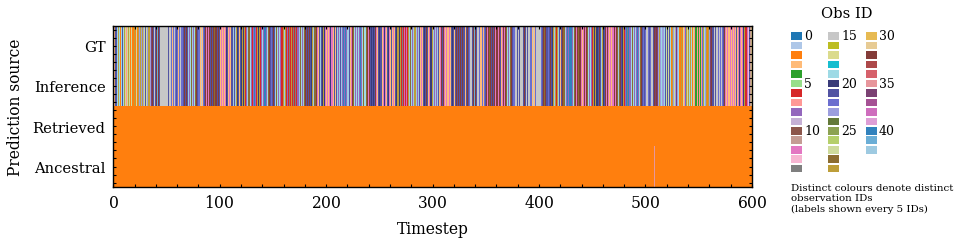


All 8 overlay entries:
  case=arena_n4 figure=arena_prediction_overlay path=figures/0000-arena-test-0000-arena_prediction_overlay.png format=png
  case=arena_n4 figure=arena_prediction_overlay path=figures/0000-arena-test-0000-arena_prediction_overlay.pdf format=pdf
  case=arena_n4 figure=arena_prediction_overlay path=figures/0001-arena-test-0001-arena_prediction_overlay.png format=png
  case=arena_n4 figure=arena_prediction_overlay path=figures/0001-arena-test-0001-arena_prediction_overlay.pdf format=pdf
  case=arena_n4 figure=arena_prediction_overlay path=figures/0002-arena-test-0002-arena_prediction_overlay.png format=png
  case=arena_n4 figure=arena_prediction_overlay path=figures/0002-arena-test-0002-arena_prediction_overlay.pdf format=pdf
  case=arena_n4 figure=arena_prediction_overlay path=figures/0003-arena-test-0003-arena_prediction_overlay.png format=png
  case=arena_n4 figure=arena_prediction_overlay path=figures/0003-arena-test-0003-arena_prediction_overlay.pdf format=pdf


In [4]:
from IPython.display import Image, display as ipy_display

figure_index = primary_report.figures()
if figure_index:
    overlay_entries = [
        e for e in figure_index.entries if e.figure_id == "arena_prediction_overlay"
    ]
    print(f"Total arena_prediction_overlay entries: {len(overlay_entries)}")

    # Display the first entry as an inline image exemplar.
    if overlay_entries:
        e = overlay_entries[0]
        abs_path = primary_report.root / e.path
        print(f"\nExemplar — case={e.regime_id} format={e.format}")
        ipy_display(Image(filename=str(abs_path)))

        # List all entries as supplementary debug info.
        print(f"\nAll {len(overlay_entries)} overlay entries:")
        for e in overlay_entries:
            print(
                f"  case={e.regime_id} figure={e.figure_id} path={e.path} format={e.format}"
            )
    else:
        print("No arena_prediction_overlay entries found in this ReportRun.")
else:
    print("No figure index in the primary ReportRun.")

## 6. Placeholder: Pathway-Stratified Reconstruction Analysis

**Purpose:** Determine whether the inference, retrieved-memory, and ancestral-structural pathways contribute differently to Arena observation reconstruction, especially on revisit steps.

**Current status:** Pending aggregation into ReportRun.

The per-step metric objects (`TEM_ACC_OBS_INFERENCE_ALL`, `TEM_ACC_OBS_RETRIEVED_ALL`, `TEM_ACC_OBS_ANCESTRAL_ALL` and their revisit counterparts) are computed during Arena TEM evaluation but the current aggregation hook only surfaces inference-pathway accuracy into the artifact summary and normalized ReportRun metrics.

**Required normalized metrics:**

- `accuracy_inference_all` / `accuracy_inference_revisit`
- `accuracy_retrieved_all` / `accuracy_retrieved_revisit`
- `accuracy_ancestral_all` / `accuracy_ancestral_revisit`

**Available now:**

- `accuracy_all` (inference pathway only, value: 1.0)
- `accuracy_revisit` (inference pathway only, value: 1.0)

**Interpretation rule:**

- Retrieval support would require retrieved-pathway accuracy to be selectively strong on revisit steps.
- Structural-prior support would require ancestral-pathway accuracy to carry useful signal, especially when sensory inference is ambiguous.
- If inference, retrieved, and ancestral streams all produce identical argmax output on this task, accuracy alone cannot distinguish structural memory from autoencoding. In that case, code-level divergence and representation geometry become the relevant evidence.

## 7. Placeholder: MEC / Grid-Like Representation Diagnostics

**Purpose:** Test whether TEM v1 structural/location representations (grid codes) exhibit grid-like spatial periodicity consistent with entorhinal-cortex-like coding.

**Required artifacts:**

- `mec_rate_maps`
- `mec_spatial_autocorrelograms`
- `mec_gridness_scores`
- `shuffle_baseline_gridness`

**Current status:** Not generated. No MEC figure family exists in any ReportRun.

**Interpretation rule:** Grid-like evidence requires autocorrelogram structure with multiple 60°/120° peaks and gridness scores above shuffled controls. Rate maps alone are insufficient.

## 8. Placeholder: HPC / Place-Like Representation Diagnostics

**Purpose:** Test whether TEM v1 sensory/location representations (place codes) exhibit place-field-like spatial tuning.

**Required artifacts:**

- `hpc_rate_maps`
- `hpc_spatial_autocorrelograms`
- `spatial_information_scores`
- `field_stability_across_episodes`

**Current status:** Not generated. No HPC figure family exists in any ReportRun.

**Interpretation rule:** Place-like evidence requires spatially localized firing fields with above-chance spatial information scores and stability across replays of the same environment.

## 9. Placeholder: Latent Structural Geometry

**Purpose:** Test whether the learned structural latent state (`g` code) is organized by spatial or graph distance rather than sensory similarity.

**Required artifacts:**

- `latent_g_pca` / `latent_g_umap`
- `latent_distance_vs_spatial_distance`
- `position_decoding_probe`

**Current status:** Not computed. Requires code extraction and analysis infrastructure.

**Interpretation rule:** Structural encoding is supported if latent `g` distances correlate with graph/spatial distances and position can be decoded from the structural state above chance.

## 10. Placeholder: Sensory / Content Representation

**Purpose:** Test whether TEM v1 observation representations (`x` / content codes) are organized by sensory identity and separable from structural codes.

**Required artifacts:**

- `content_x_pca` / `content_x_umap`
- `observation_confusion_matrix`
- `content_vs_structure_cross_correlation`

**Current status:** Not computed.

**Interpretation rule:** Sensory/structure factorization is supported if content codes cluster by observation ID while structural codes cluster by spatial position, with limited cross-correlation.

## 11. Placeholder: Remapping and Structural Reuse

**Purpose:** Test whether TEM v1 structural codes are preserved when the same graph topology is overlaid with different sensory observations (remapping).

**Required artifacts:**

- `remapping_structural_code_similarity`
- `remapping_sensory_code_divergence`
- `few_shot_adaptation_curves`

**Current status:** Not evaluated. Requires a remapping dataset variant.

**Interpretation rule:** Structural reuse is supported if structural codes remain similar across remapped environments despite diverging sensory codes, and if the model adapts faster to remapped variants than to novel topologies.

## 12. Placeholder: Failure Analysis

**Purpose:** Identify systematic failure modes in TEM v1 observation reconstruction.

**Required artifacts:**

- `worst_rollouts`
- `error_by_position`
- `confidence_vs_correctness`
- `pathway_specific_failure_cases`

**Current status:** Not computed.

**Interpretation rule:** Systematic failures (e.g., errors concentrated at specific graph positions or sensory identities) would point to limitations in the structural code or decoder capacity.

## 13. Checkpoint Readiness / Evidence Quality

| Model  | Checkpoint status |        Training progress | Evidence status  | Interpretation                            |
| ------ | ----------------- | -----------------------: | ---------------- | ----------------------------------------- |
| TEM v1 | trained           | global_step=10000, e=100 | primary evidence | interpretable bounded-validation evidence |
| TEM v2 | undertrained      |      global_step=76, e=0 | diagnostic only  | not a valid comparator                    |
| EHC v1 | undertrained      |       global_step=1, e=1 | diagnostic only  | not a valid comparator                    |

**Key statement:** The current report validates the reporting/evidence pipeline for all three families, but only TEM v1 currently has a checkpoint suitable for scientific interpretation.

## 14. Diagnostic Appendix: TEM v2 and EHC v1 Pipeline Readiness

The diagnostic ReportRuns below confirm that the eval, trace materialization, figure generation, and reporting pipeline is functional for TEM v2 and EHC v1. However, their checkpoints are undertrained (TEM v2: 76 gradient steps; EHC v1: 1 gradient step) and do not support scientific comparison with TEM v1.

```python
from ehc_sn.reporting import open_report

diagnostic_reports = {
    "TEM v2": open_report("/home/borja/ehc-sn/artifacts/reports/tem_v2/arena_struct_val_8"),
    "EHC v1": open_report("/home/borja/ehc-sn/artifacts/reports/ehc_v1/arena_struct_val_8"),
}

for name, report in diagnostic_reports.items():
    metrics = {m.metric: m.value for m in report.metrics()}
    figs = report.figures()
    print(f"{name}: accuracy_all={metrics.get('accuracy_all'):.6f} "
          f"accuracy_revisit={metrics.get('accuracy_revisit'):.6f} "
          f"figures={len(figs.entries) if figs else 0}")
```

## 15. Claim / Evidence / Verdict Summary

| Claim                                                            | Current evidence                              | Verdict                       |
| ---------------------------------------------------------------- | --------------------------------------------- | ----------------------------- |
| TEM v1 reconstructs Arena observations through inference pathway | `accuracy_all`, `accuracy_revisit`            | ✅ Supported on bounded val_8 |
| TEM v1 exposes retrieved and ancestral prediction streams        | `arena_prediction_overlay` argmax overlays    | ✅ Qualitatively inspectable  |
| Retrieved/ancestral pathways aid revisit reconstruction          | Not aggregated into ReportRun                 | ⏳ Pending                    |
| Pathways differ in confidence or uncertainty                     | Logits/top-k not surfaced                     | ⏳ Pending                    |
| TEM v1 learns grid-like structural codes                         | No MEC/autocorr figures yet                   | ❌ Pending                    |
| TEM v1 forms place-like representations                          | No HPC/place-map figures yet                  | ❌ Pending                    |
| TEM separates structure from sensory content                     | No `g`/`x` geometry or remapping evidence yet | ❌ Pending                    |
| TEM generalizes reusable structure across sensory remaps         | No remapping/generalization artifact          | ❌ Pending                    |
| TEM v1 outperforms TEM v2/EHC                                    | TEM v2/EHC checkpoints undertrained           | ❌ Not evaluated              |

## 16. Next Milestones

The report is a scaffold for the TEM structural-memory hypothesis. The next major workstream is one of two paths:

### Path 1: TEM v1 mechanistic depth (recommended now)

Add representation diagnostics for TEM v1 only:

1. Pathway-stratified accuracy aggregation (extend aggregation hook to surface retrieved and ancestral metrics).
2. MEC/grid-like rate maps and autocorrelograms.
3. HPC/place-like rate maps and spatial tuning.
4. Latent `g` geometry and position decoding probes.
5. Sensory/content representation analysis.
6. Remapping and generalization evaluation.

### Path 2: Comparative report readiness (blocked until checkpoints exist)

Make TEM v2 and EHC v1 valid scientific comparators:

1. Train or locate valid TEM v2 Arena checkpoint.
2. Train or locate valid EHC v1 Arena checkpoint.
3. Export compatible eval-weights-only checkpoints.
4. Re-run Arena val/test ReportRuns.
5. Only then compare metrics and figures across model families.

---

_This notebook is a report viewer. Narrative structure is permanent; numbers are replaceable as ReportRuns become available._
